In [1]:
from google.colab import drive

drive.mount('/content/drive')
import os


Mounted at /content/drive


In [2]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive/archive (7)"):
    for file in files:
        print(os.path.join(root, file))

In [3]:
import pandas as pd

file_path = '/content/drive/MyDrive/sonu project/archive (7)/pattern_classifications.csv'

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.head()

Dataset shape: (2700, 2)

Columns:
Index(['Pattern String', 'classification'], dtype='object')


,Pattern String,classification
0,FREE SHIPPING ON ORDERS OVER $100!,0.0
1,SOME EXCLUSIONS APPLY - LEARN MORE,0.0
2,HAVE A QUESTION? - CONTACT US,0.0
3,WELCOME TO 034MOTORSPORT!,0.0
4,SHOP AUDISHOP VOLKSWAGENPERFORMANCE SOFTWARE03...,0.0


In [4]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df['classification'].value_counts(dropna=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2700 entries, 0 to 2699
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Pattern String  2427 non-null   object 
 1   classification  2699 non-null   float64
dtypes: float64(1), object(1)
memory usage: 42.3+ KB
None

Missing values:
Pattern String    273
classification      1
dtype: int64

Class distribution:
classification
0.0    2094
1.0     605
NaN       1
Name: count, dtype: int64


In [5]:
# Remove rows where text or classification is missing
df = df.dropna(subset=['Pattern String', 'classification'])

# Convert text to string
df['Pattern String'] = df['Pattern String'].astype(str)

# Convert classification to integer
df['classification'] = df['classification'].astype(int)

print("Dataset after cleaning:", df.shape)

print(df.head())

Dataset after cleaning: (2426, 2)
                                      Pattern String  classification
0                 FREE SHIPPING ON ORDERS OVER $100!               0
1                 SOME EXCLUSIONS APPLY - LEARN MORE               0
2                      HAVE A QUESTION? - CONTACT US               0
3                          WELCOME TO 034MOTORSPORT!               0
4  SHOP AUDISHOP VOLKSWAGENPERFORMANCE SOFTWARE03...               0


In [6]:
X = df['Pattern String']
y = df['classification']

print("Number of text samples:", len(X))
print("Number of labels:", len(y))

Number of text samples: 2426
Number of labels: 2426


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1940
Testing samples: 486


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 2),
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (1940, 5000)
Testing TF-IDF shape: (486, 5000)


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [10]:
y_pred = rf_model.predict(X_test_tfidf)

print("Predictions:")
print(y_pred[:20])

Predictions:
[1 0 0 1 1 0 0 1 0 1 1 0 0 1 0 0 0 1 0 1]


In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Deceptive', 'Deceptive']
))

Accuracy : 0.6748971193415638
Precision: 0.373134328358209
Recall   : 0.7009345794392523
F1 Score : 0.487012987012987

Classification Report:
               precision    recall  f1-score   support

Not Deceptive       0.89      0.67      0.76       379
    Deceptive       0.37      0.70      0.49       107

     accuracy                           0.67       486
    macro avg       0.63      0.68      0.62       486
 weighted avg       0.77      0.67      0.70       486



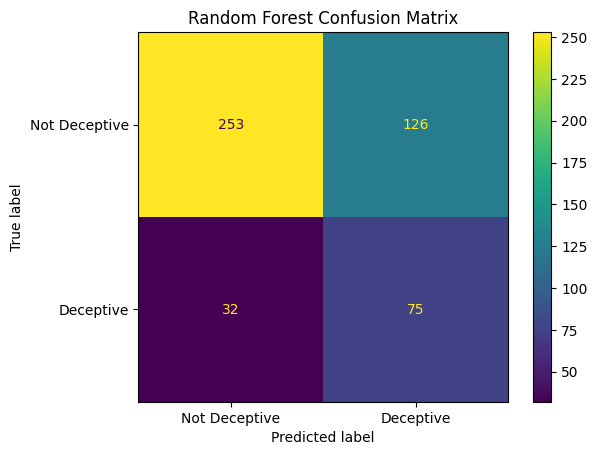

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Deceptive', 'Deceptive']
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [13]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

print("Logistic Regression Results")
print("--------------------------------")

print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall   :", recall_score(y_test, lr_pred))
print("F1 Score :", f1_score(y_test, lr_pred))

Logistic Regression Results
--------------------------------
Accuracy : 0.8415637860082305
Precision: 0.6744186046511628
Recall   : 0.5420560747663551
F1 Score : 0.6010362694300518


In [14]:
while True:
    text = input("\nEnter a pattern (or type 'exit' to stop): ")

    if text.lower() == "exit":
        print("Prediction system stopped.")
        break

    # Convert input text to TF-IDF
    text_tfidf = tfidf.transform([text])

    # Logistic Regression prediction
    prediction = lr_model.predict(text_tfidf)[0]
    probability = lr_model.predict_proba(text_tfidf)[0]

    # Convert prediction to label
    if prediction == 1:
        result = "DECEPTIVE PATTERN"
    else:
        result = "NOT DECEPTIVE"

    # Confidence
    confidence = max(probability) * 100

    print("\nPrediction:", result)
    print("Confidence:", round(confidence, 2), "%")
    # Not Deceptive=safe(0)
    # deceptive=fraud/manipulating(1)


Enter a pattern (or type 'exit' to stop): SALE

Prediction: DECEPTIVE PATTERN
Confidence: 58.06 %

Enter a pattern (or type 'exit' to stop): Only 10 piece left

Prediction: NOT DECEPTIVE
Confidence: 81.17 %

Enter a pattern (or type 'exit' to stop): address

Prediction: NOT DECEPTIVE
Confidence: 62.19 %

Enter a pattern (or type 'exit' to stop): offer only for today grab now

Prediction: NOT DECEPTIVE
Confidence: 51.53 %

Enter a pattern (or type 'exit' to stop): contact only to us

Prediction: NOT DECEPTIVE
Confidence: 85.03 %

Enter a pattern (or type 'exit' to stop): youtube

Prediction: DECEPTIVE PATTERN
Confidence: 79.08 %

Enter a pattern (or type 'exit' to stop): login

Prediction: NOT DECEPTIVE
Confidence: 60.67 %

Enter a pattern (or type 'exit' to stop): exit
Prediction system stopped.


In [15]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, lr_pred)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, lr_pred)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, lr_pred)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, lr_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.674897,0.373134,0.700935,0.487013
1,Logistic Regression,0.841564,0.674419,0.542056,0.601036
